# Multicollinearity
pip install  statsmodels

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## check for correlations

In [30]:
df=pd.read_csv('salary_dataset.csv')
df.head()

,gender,age,years_of_service,education_level,performance_score,team_size_managed,salary
0,0,39,17,2,74.21,37,82497
1,1,47,20,2,60.66,168,78701
2,0,55,26,2,66.88,115,89645
3,0,31,7,2,62.60,17,61360
4,0,57,24,1,61.16,241,99381


# Observation
Here Gender and Educatin  level are categorical values. So for this multilcollinearity analysis, we can drop them.

In [31]:
df_original = df.copy()
df = df.drop(columns=['gender', 'education_level'])

correlation matrix: 
                        age  years_of_service  performance_score  \
age                1.000000          0.977642           0.146732   
years_of_service   0.977642          1.000000           0.102586   
performance_score  0.146732          0.102586           1.000000   
team_size_managed  0.051174          0.058642           0.003166   
salary             0.861659          0.862576           0.388856   

                   team_size_managed    salary  
age                         0.051174  0.861659  
years_of_service            0.058642  0.862576  
performance_score           0.003166  0.388856  
team_size_managed           1.000000  0.139534  
salary                      0.139534  1.000000  
########################################


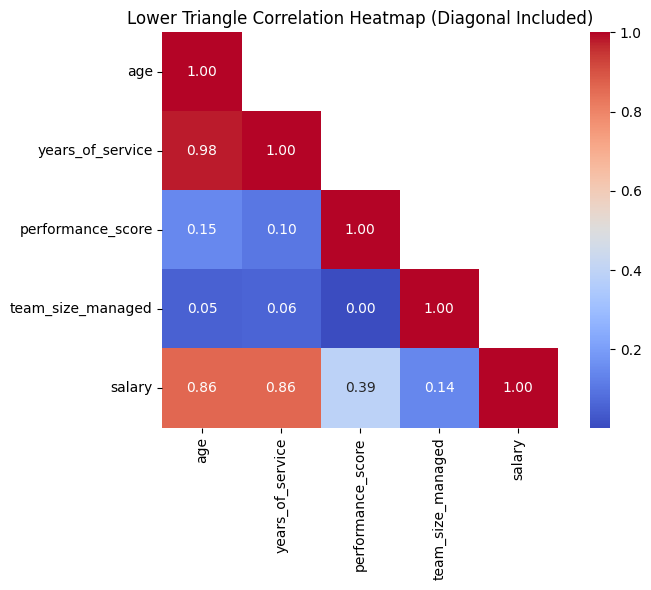

In [32]:
corr_matrix = df.corr(method='pearson', numeric_only=True) # method='spearman',etc
print(f"correlation matrix: \n{corr_matrix}")
print("########################################")
# Plot heatmap
# Create a mask for the upper triangle *excluding* the diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Draw the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True)

plt.title("Lower Triangle Correlation Heatmap (Diagonal Included)")
plt.tight_layout()
plt.show()

## observation
age and Years_of_service are highly correlated

## check VIF (Variance Inflation Factor)

In [33]:
# Import library for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [34]:
X = df.iloc[:,:-1]
calc_vif(X)

,variables,VIF
0,age,115.143762
1,years_of_service,34.727348
2,performance_score,33.917964
3,team_size_managed,1.786951


## observation
‘Age’ , ‘Years of service’, 'performance_score' have a high VIF value, meaning they can be predicted by other independent variables in the dataset.

## Remedy 1: Drop feature
Here we drop the Age column because it has maximum VIF. This is an iterative process: drop a column, calculate VIF, then drop column again if necessary else stop.

Note as we drop the columns, the VIF changes.

In [35]:
X = df.drop(['age','salary'],axis=1)
calc_vif(X) # NOTE The VIF will drop

,variables,VIF
0,years_of_service,3.782356
1,performance_score,4.299393
2,team_size_managed,1.771755


## Remedy 2: combine features
Combining ‘Age’ and ‘Years of experience’  into a single variable, ‘Age_at_joining’ allows us to capture the information in both variables.

In [36]:
df2 = df.copy()
df2['age_at_joining'] = df.apply(lambda x: x['age'] - x['years_of_service'],axis=1)
X = df2.drop(['age','years_of_service','salary'],axis=1)

calc_vif(X) # NOTE The VIF will drop

,variables,VIF
0,performance_score,31.902378
1,team_size_managed,1.785968
2,age_at_joining,32.339650


## Observation
Here although the VIF for performance score and age_at_joing are high, we cannot combine them. So thats it for combining features

## Remedy 3 : Use dimension reduction  technique (Like PCA,etc)
Here there are only 2 numeric columns Age and Years_of_service, so PCA is not going to help much

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Drop non-numeric columns if any, or select numeric ones
X = df[['age', 'years_of_service', 'performance_score', ]]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio per component:", explained_variance)

# 4. Optional: Cumulative explained variance
cumulative_variance = explained_variance.cumsum()
print("Cumulative explained variance:", cumulative_variance)

Explained variance ratio per component: [0.66949176 0.3233928  0.00711544]
Cumulative explained variance: [0.66949176 0.99288456 1.        ]


## observation
So 98% is explained by 1st 2 PC. Good. We keep this one.

In [38]:
# Extract both PC1 and PC2 from X_pca
pcs = X_pca[:, :2]  # This slices both PC1 and PC2 and keeps 2D shape

# Create a DataFrame with both components
X = pd.DataFrame(pcs, columns=['PC1', 'PC2'])

# pca_df['salary'] = df['salary'].values
print(X)

calc_vif(X)

         PC1       PC2
0   0.063547  0.209147
1   0.612538 -1.016147
2   1.677584 -0.678609
3  -1.390437 -0.502744
4   1.567025 -1.130366
..       ...       ...
95  2.034168 -1.143203
96  1.574094 -1.360020
97  0.650950 -0.052553
98 -0.816032  0.457438
99  1.684396  1.952646

[100 rows x 2 columns]


,variables,VIF
0,PC1,1.0
1,PC2,1.0


## Observation
Good 

# Conclusion
After the above analysis, make sure to include the gender and education_level(the ones we dropped in the beginning) and salary in  the dataframe to continue with further process.